In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [ ]:
# Importação das bibliotecas necessárias

from sklearn.model_selection import train_test_split
from modulos.gerais import preparar_heart_disease, padronizar_dados_de_treino
from modulos.knn import (
    preparar_knn, treinar_k, atualizar_melhor_desempenho_k, exibir_melhor_resultado_do_knn, 
    exibir_grafico_comparativo, exibir_resultados_do_knn
    )


In [3]:
# Importação e exploração dos dados
X, y, feature_names, target_names = preparar_heart_disease()

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)

# Padronização obrigatório para o KNN não "quebrar" com os valores de colesterol
X_train_padronizado, X_test_padronizado = padronizar_dados_de_treino(X_train, X_test)


In [4]:
#Estabelecendo as variáveis que serão usadas no loop do KNN
valores_k, resultados_acuracia, melhor_k, melhor_f1 = preparar_knn()


In [ ]:
for k in valores_k:
    # Treinando e avaliando o modelo de acordo com o K atual
    y_pred_knn, acuracia_knn, precisao_knn, revocacao_knn, f1_knn = treinar_k(
        k, resultados_acuracia, X_train, y_train, X_test, y_test
    )

    # Exibindo o resultado do K atual
    exibir_resultados_do_knn(acuracia_knn, precisao_knn, revocacao_knn, f1_knn, k, y_test, y_pred_knn, target_names)

    # Atualizando qual é o melhor modelo baseado no F1-Score
    melhor_f1, melhor_k = atualizar_melhor_desempenho_k(f1_knn, k, melhor_f1, melhor_k)


MÉTRICAS DE AVALIAÇÃO - KNN (K = 1)
Acurácia:  0.6333
Precisão:  0.6340
Revocação: 0.6250
F1-Score:  0.6229
MÉTRICAS DE AVALIAÇÃO - KNN (K = 3)
Acurácia:  0.6556
Precisão:  0.6545
Revocação: 0.6503
F1-Score:  0.6503
MÉTRICAS DE AVALIAÇÃO - KNN (K = 5)
Acurácia:  0.6222
Precisão:  0.6213
Revocação: 0.6146
F1-Score:  0.6129
MÉTRICAS DE AVALIAÇÃO - KNN (K = 7)
Acurácia:  0.6444
Precisão:  0.6450
Revocação: 0.6369
F1-Score:  0.6356
MÉTRICAS DE AVALIAÇÃO - KNN (K = 9)
Acurácia:  0.6333
Precisão:  0.6325
Revocação: 0.6265
F1-Score:  0.6255
MÉTRICAS DE AVALIAÇÃO - KNN (K = 11)
Acurácia:  0.5889
Precisão:  0.5857
Revocação: 0.5818
F1-Score:  0.5801
CONCLUSÃO: O melhor desempenho foi com K = 3 (F1-Score: 0.6503)


In [ ]:
# Exibição do melhor K testado
exibir_melhor_resultado_do_knn(melhor_k, melhor_f1)


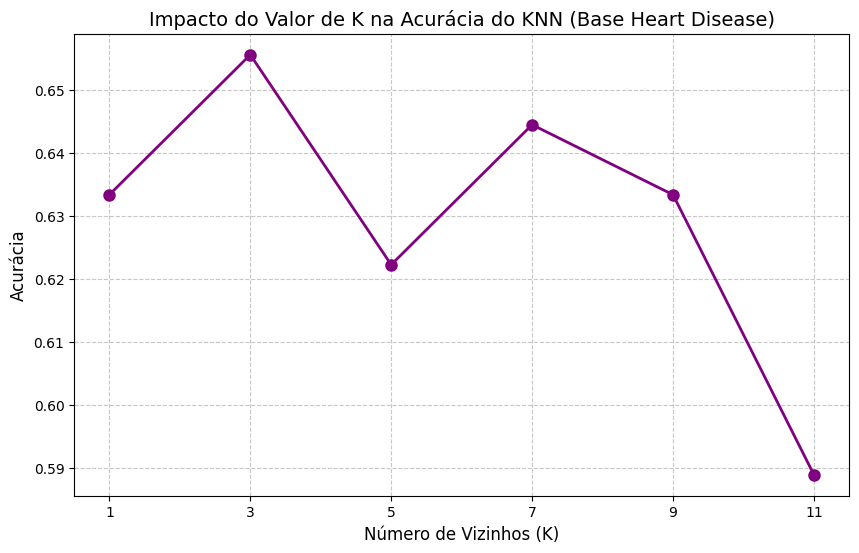

In [6]:
# Representação gráfica dos valores de K usados no KNN
exibir_grafico_comparativo(valores_k, resultados_acuracia, "Heart Disease")
